# RPG Graph Analysis: Sports and Outdoors

Dataset-specific graph-analysis notebook for `sports`. It reads the completed static A, dynamic B, scoring C, and no-trace perf outputs from the matching graph-analysis session. Use `cross_dataset_comparison.ipynb` for side-by-side plots across datasets.


In [1]:
from pathlib import Path
import json
import os
import tempfile

os.environ.setdefault('MPLCONFIGDIR', str(Path(tempfile.gettempdir()) / 'rpg-matplotlib'))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

REPO_ROOT = Path.cwd().resolve()
while REPO_ROOT.name != 'RPG' and REPO_ROOT.parent != REPO_ROOT:
    REPO_ROOT = REPO_ROOT.parent

GRAPH_ROOT = REPO_ROOT / 'artifacts' / 'rpg' / 'graph_analysis' / 'sports'
sessions = sorted(p for p in GRAPH_ROOT.iterdir() if (p / 'static' / 'static_summary.csv').is_file())
if not sessions:
    raise FileNotFoundError(f'No completed static graph-analysis sessions found under {GRAPH_ROOT}')
SESSION = sessions[-1]
manifest = json.loads((SESSION / 'manifest.json').read_text())
graph_metadata = json.loads(Path(manifest['graph_metadata']).read_text())
n_digit = int(graph_metadata['n_digit'])
STATIC = SESSION / 'static'
DYNAMIC = SESSION / 'dynamic'

print(SESSION)
print(f"Semantic-ID digits: {n_digit}")
manifest

/gpfs/home6/scur1202/RPG/artifacts/rpg/graph_analysis/sports/20260615T153949Z_job23882755
Semantic-ID digits: 16


{'adjacency': '/gpfs/home6/scur1202/RPG/artifacts/rpg/graph_analysis/sports/20260615T153949Z_job23882755/graphs/adjacency_top100.pt',
 'dynamic_outputs': {'first_hit_csv': '/gpfs/home6/scur1202/RPG/artifacts/rpg/graph_analysis/sports/20260615T153949Z_job23882755/dynamic/summaries/dynamic_first_hit_summary.csv',
  'per_example_parquet': '/gpfs/home6/scur1202/RPG/artifacts/rpg/graph_analysis/sports/20260615T153949Z_job23882755/dynamic/per_example.parquet',
  'reachability_csv': '/gpfs/home6/scur1202/RPG/artifacts/rpg/graph_analysis/sports/20260615T153949Z_job23882755/dynamic/summaries/dynamic_reachability_summary.csv',
  'redundancy_csv': '/gpfs/home6/scur1202/RPG/artifacts/rpg/graph_analysis/sports/20260615T153949Z_job23882755/dynamic/summaries/dynamic_redundancy_summary.csv',
  'sample_traces_jsonl': '/gpfs/home6/scur1202/RPG/artifacts/rpg/graph_analysis/sports/20260615T153949Z_job23882755/dynamic/traces/sample_traces.jsonl',
  'saturation_csv': '/gpfs/home6/scur1202/RPG/artifacts/rpg/

Load the CSV files produced by the static analysis job. `summary` is the main table; the other files are used for histograms and per-item plots.


In [2]:
summary = pd.read_csv(STATIC / 'static_summary.csv')
similarity_hist = pd.read_csv(STATIC / 'edge_similarity_histogram.csv')
hamming_hist = pd.read_csv(STATIC / 'hamming_histogram.csv')
indegree_hist = pd.read_csv(STATIC / 'indegree_histogram.csv')
popularity_buckets = pd.read_csv(STATIC / 'popularity_buckets.csv')
item_metrics = pd.read_csv(STATIC / 'item_metrics_by_k.csv')

summary

,k,n_nodes,n_edges,edge_similarity_mean,edge_similarity_median,edge_similarity_p10,edge_similarity_p90,random_similarity_mean,random_similarity_median,random_similarity_p10,...,spearman_train_frequency_indegree,spearman_pvalue,pearson_log1p_train_frequency_log1p_indegree,pearson_pvalue,top_1pct_hub_count,top_1pct_hub_train_frequency_mean,top_1pct_hub_train_frequency_median,top_1pct_hub_training_interaction_share,all_items_train_frequency_mean,all_items_train_frequency_median
0,10,18357,165213,0.637190,0.604872,0.575371,0.746529,0.501210,0.499814,0.485925,...,0.140679,8.897142e-82,0.142305,1.183173e-83,184,16.157609,7.5,0.013205,12.264586,7.0
1,20,18357,348783,0.612052,0.586518,0.568861,0.686294,0.501204,0.499810,0.485915,...,0.146625,9.526133e-89,0.150757,9.096565e-94,184,19.114130,8.0,0.015621,12.264586,7.0
2,30,18357,532353,0.599198,0.577130,0.564451,0.656955,0.501220,0.499822,0.485925,...,0.142444,8.168400e-84,0.151204,2.550573e-94,184,19.456522,9.0,0.015901,12.264586,7.0
3,50,18357,899493,0.585043,0.569397,0.557759,0.625821,0.501215,0.499816,0.485915,...,0.134131,1.906068e-74,0.143015,1.765462e-84,184,19.744565,9.0,0.016137,12.264586,7.0
4,100,18357,1817343,0.569229,0.558790,0.549423,0.593001,0.501213,0.499824,0.485909,...,0.136399,6.054224e-77,0.147655,5.514812e-90,184,25.570652,9.0,0.020898,12.264586,7.0


## Edge Similarity and Hamming Distance


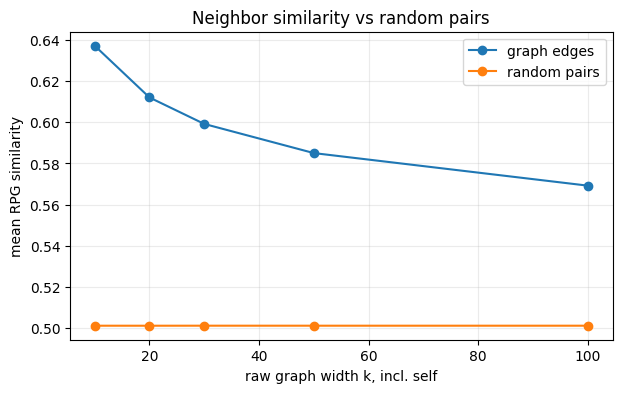

,k,hamming_mean,random_hamming_mean,matching_digits_mean,random_matching_digits_mean
0,10,11.889107,15.928291,4.110893,0.071709
1,20,12.698675,15.928341,3.301325,0.071659
2,30,13.100076,15.928237,2.899924,0.071763
3,50,13.552326,15.928057,2.447674,0.071943
4,100,14.133754,15.928165,1.866246,0.071835


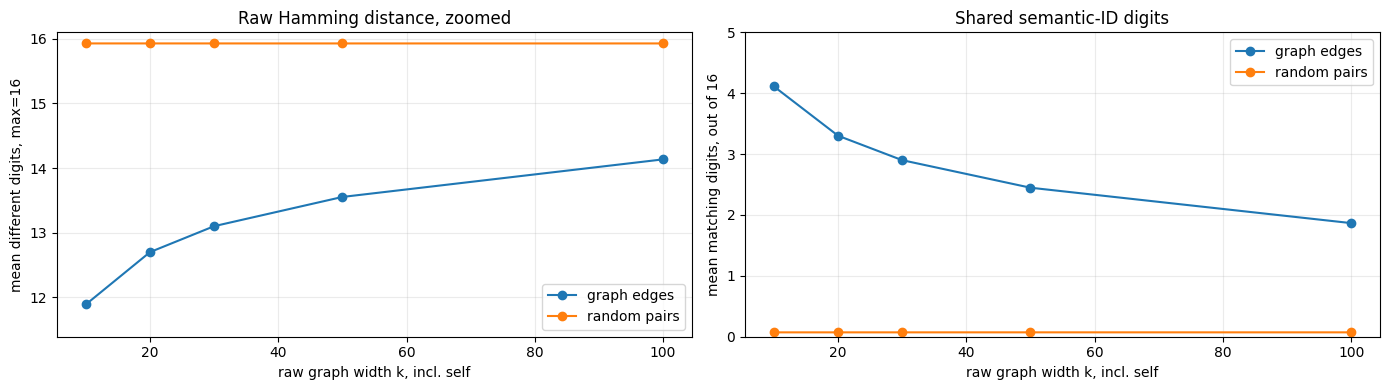

In [3]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(summary['k'], summary['edge_similarity_mean'], marker='o', label='graph edges')
ax.plot(summary['k'], summary['random_similarity_mean'], marker='o', label='random pairs')
ax.set_xlabel('raw graph width k, incl. self')
ax.set_ylabel('mean RPG similarity')
ax.set_title('Neighbor similarity vs random pairs')
ax.legend()
ax.grid(alpha=0.25)
plt.show()

a2 = summary.assign(
    matching_digits_mean=n_digit - summary['hamming_mean'],
    random_matching_digits_mean=n_digit - summary['random_hamming_mean'],
)

display(a2[[
    'k',
    'hamming_mean',
    'random_hamming_mean',
    'matching_digits_mean',
    'random_matching_digits_mean',
]])

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(summary['k'], summary['hamming_mean'], marker='o', label='graph edges')
axes[0].plot(summary['k'], summary['random_hamming_mean'], marker='o', label='random pairs')
axes[0].set_xlabel('raw graph width k, incl. self')
axes[0].set_ylabel(f'mean different digits, max={n_digit}')
axes[0].set_title('Raw Hamming distance, zoomed')
axes[0].set_ylim(max(0, summary['hamming_mean'].min() - 0.5), n_digit + 0.1)
axes[0].legend()

axes[1].plot(a2['k'], a2['matching_digits_mean'], marker='o', label='graph edges')
axes[1].plot(a2['k'], a2['random_matching_digits_mean'], marker='o', label='random pairs')
axes[1].set_xlabel('raw graph width k, incl. self')
axes[1].set_ylabel(f'mean matching digits, out of {n_digit}')
axes[1].set_title('Shared semantic-ID digits')
axes[1].set_ylim(0, max(5, a2['matching_digits_mean'].max() + 0.5))
axes[1].legend()

for axis in axes:
    axis.grid(alpha=0.25)
plt.tight_layout()
plt.show()

- `RPG similarity` is the embedding similarity used to construct the graph. If graph edges are above random pairs, the graph is not arbitrary.
- `Hamming distance` counts how many semantic-ID digits differ. The maximum is this dataset's `n_digit`.
- `matching_digits = n_digit - hamming` is easier to read: larger values mean the two items share more semantic-ID structure.
- Main takeaway to check: graph neighbors should share much more ID structure than random item pairs, but they are not necessarily almost-identical IDs.


## Static Structure

This is the main structural part of the analysis: reciprocity, connected components, and local clustering.


The plots below ask three different questions: are edges symmetric, is the graph already connected, and are neighborhoods locally redundant?


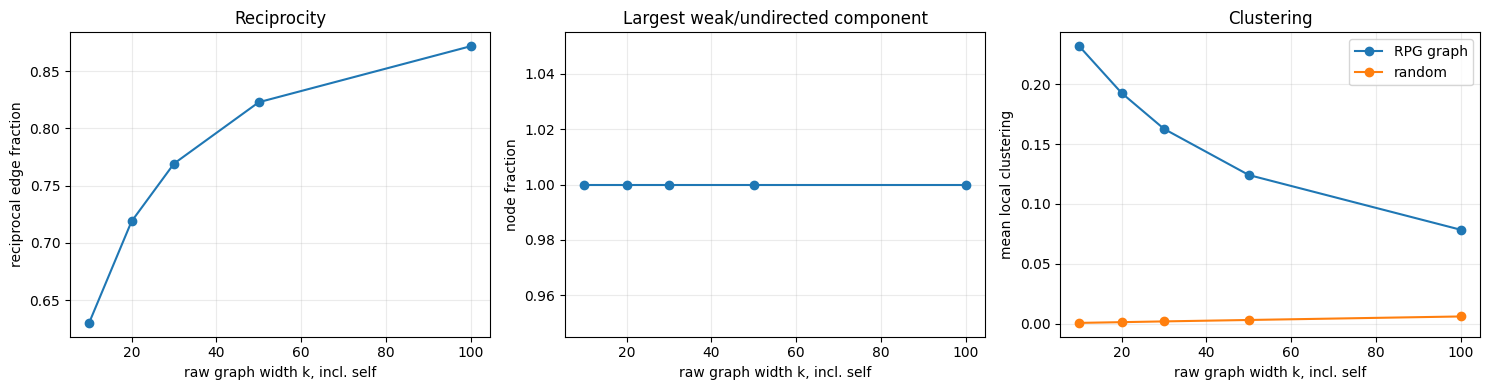

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(summary['k'], summary['reciprocity'], marker='o')
axes[0].set_title('Reciprocity')
axes[0].set_xlabel('raw graph width k, incl. self')
axes[0].set_ylabel('reciprocal edge fraction')

axes[1].plot(summary['k'], summary['largest_component_fraction'], marker='o')
axes[1].set_title('Largest weak/undirected component')
axes[1].set_xlabel('raw graph width k, incl. self')
axes[1].set_ylabel('node fraction')

axes[2].plot(summary['k'], summary['clustering_mean'], marker='o', label='RPG graph')
axes[2].plot(summary['k'], summary['random_clustering_mean'], marker='o', label='random')
axes[2].set_title('Clustering')
axes[2].set_xlabel('raw graph width k, incl. self')
axes[2].set_ylabel('mean local clustering')
axes[2].legend()

for axis in axes:
    axis.grid(alpha=0.25)
plt.tight_layout()
plt.show()

In [5]:
static_structure_table = (
    summary[[
        'k',
        'n_components',
        'largest_component_fraction',
        'clustering_mean',
        'random_clustering_mean',
        'clustering_lift_over_random',
    ]]
    .rename(columns={
        'k': 'raw_graph_width_k_incl_self',
        'largest_component_fraction': 'largest_component_fraction',
        'clustering_mean': 'rpg_clustering',
        'random_clustering_mean': 'random_clustering',
        'clustering_lift_over_random': 'clustering_lift',
    })
    .round({
        'largest_component_fraction': 4,
        'rpg_clustering': 6,
        'random_clustering': 6,
        'clustering_lift': 2,
    })
)

static_structure_table


,raw_graph_width_k_incl_self,n_components,largest_component_fraction,rpg_clustering,random_clustering,clustering_lift
0,10,1,1.0,0.231703,0.000714,324.35
1,20,1,1.0,0.192612,0.001315,146.44
2,30,1,1.0,0.162657,0.001960,82.98
3,50,1,1.0,0.124130,0.003141,39.52
4,100,1,1.0,0.078408,0.006082,12.89


### Directed Strong Connectivity

The largest-component plot above ignores edge direction. Since directed graph search can be limited by direction, this cell also computes strongly connected components from the cached directed adjacency. This uses the saved top-100 graph only; it does not rerun RPG evaluation or rebuild the graph.

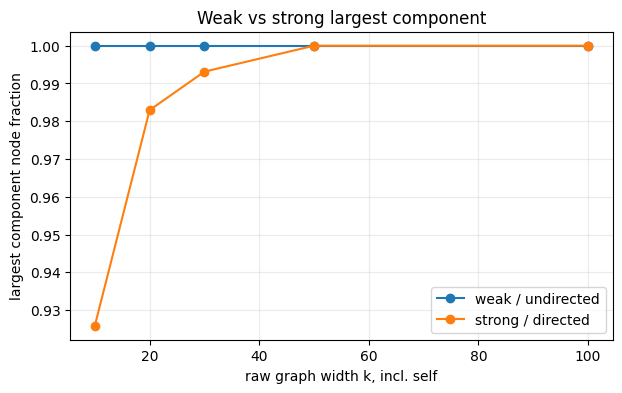

,k,n_strong_components,largest_strong_component_size,largest_strong_component_fraction,second_largest_strong_component_size,weak_largest_component_fraction
0,10,328,16996,0.925859,53,1.0
1,20,29,18044,0.982949,45,1.0
2,30,6,18231,0.993136,44,1.0
3,50,1,18357,1.000000,0,1.0
4,100,1,18357,1.000000,0,1.0


In [6]:
import torch
import igraph as ig

adjacency_path = SESSION / 'graphs' / f"adjacency_top{int(graph_metadata['topk'])}.pt"
adjacency = torch.load(adjacency_path, map_location='cpu').numpy()
n_real_items = int(graph_metadata['n_real_items'])

strong_rows = []
for k in summary['k'].astype(int):
    source_items = np.arange(1, adjacency.shape[0], dtype=np.int64)
    neighbors = adjacency[1:, :k].astype(np.int64, copy=False)
    sources = np.repeat(source_items, k)
    destinations = neighbors.reshape(-1)
    mask = (destinations > 0) & (destinations != sources)
    edges = list(zip((sources[mask] - 1).tolist(), (destinations[mask] - 1).tolist()))

    directed_graph = ig.Graph(n=n_real_items, edges=edges, directed=True)
    directed_graph.simplify(multiple=True, loops=True)

    strong_components = directed_graph.connected_components(mode='strong')
    strong_sizes = np.array(strong_components.sizes(), dtype=np.int64)
    strong_sorted = np.sort(strong_sizes)[::-1]
    largest_strong = int(strong_sorted[0]) if strong_sorted.size else 0
    second_strong = int(strong_sorted[1]) if strong_sorted.size > 1 else 0

    strong_rows.append({
        'k': k,
        'n_strong_components': int(strong_sizes.size),
        'largest_strong_component_size': largest_strong,
        'largest_strong_component_fraction': largest_strong / n_real_items,
        'second_largest_strong_component_size': second_strong,
        'weak_largest_component_fraction': float(summary.loc[summary['k'] == k, 'largest_component_fraction'].iloc[0]),
    })

strong_components = pd.DataFrame(strong_rows)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(strong_components['k'], strong_components['weak_largest_component_fraction'], marker='o', label='weak / undirected')
ax.plot(strong_components['k'], strong_components['largest_strong_component_fraction'], marker='o', label='strong / directed')
ax.set_xlabel('raw graph width k, incl. self')
ax.set_ylabel('largest component node fraction')
ax.set_title('Weak vs strong largest component')
ax.grid(alpha=0.25)
ax.legend()
plt.show()

display(strong_components)


After running the cell above, read this as the directed analogue of the largest-component plot. The weak component result ignores edge direction; the strong component result asks whether directed graph traversal can move between items both ways. Use the printed fractions for this dataset instead of copying another dataset's numbers.


- These values are unitless. They are fractions or ratios, not counts.
- `Reciprocity`: among directed edges `i -> j`, how often the reverse edge `j -> i` also exists. High values mean neighborhoods are fairly symmetric.
- `Largest weak/undirected component fraction`: fraction of items in the biggest connected component after ignoring edge direction. This answers whether the graph is fragmented if direction is ignored.
- `Largest strong/directed component fraction`: fraction of items in the biggest strongly connected component when edge direction is respected. This is stricter and more relevant for directed graph search.
- `RPG clustering`: for each item, look at its neighbors and ask how many neighbor-neighbor links exist among them. Then average over items.
- `Random clustering`: the same calculation on a random graph with comparable size.
- `Clustering lift`: RPG clustering divided by random clustering. Values above `1` mean RPG has more local closure than chance.
- Main takeaway: weak connectivity says the graph is not globally fragmented if direction is ignored. The strong-component table is the safer directed-search check; clustering remains the main signal for local redundancy.


## Hubness

Here we check whether a small number of items attract many incoming graph edges. This matters because saturation could also happen if graph expansion keeps returning the same hubs.


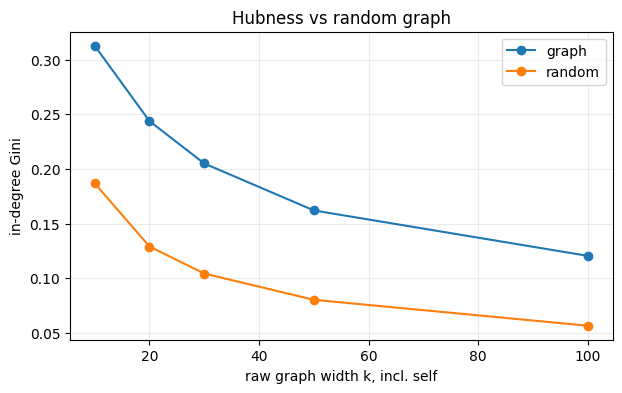

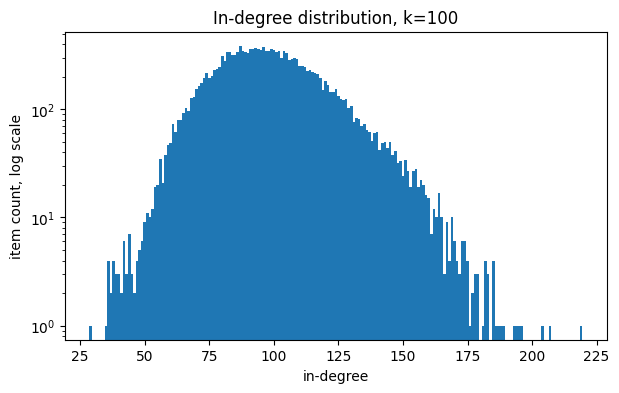

In [7]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(summary['k'], summary['indegree_gini'], marker='o', label='graph')
ax.plot(summary['k'], summary['random_indegree_gini_mean'], marker='o', label='random')
ax.set_xlabel('raw graph width k, incl. self')
ax.set_ylabel('in-degree Gini')
ax.set_title('Hubness vs random graph')
ax.legend()
ax.grid(alpha=0.25)
plt.show()

k = int(summary['k'].max())
hist = indegree_hist[indegree_hist['k'] == k]
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(hist['indegree'], hist['count'], width=1.0)
ax.set_yscale('log')
ax.set_xlabel('in-degree')
ax.set_ylabel('item count, log scale')
ax.set_title(f'In-degree distribution, k={k}')
plt.show()

- `In-degree`: how often an item appears in other items' neighbor lists.
- `Gini`: inequality of in-degree. `0` means perfectly uniform; higher values mean stronger hubs.
- The histogram shows how many items have each in-degree at the largest `k`, using a log y-axis.
- Main takeaway: hubs exist, but the effect is not extreme and it weakens as `k` increases.


## Popularity Bias

This checks whether graph hubs are simply popular training items. If yes, the graph might mostly be amplifying popularity rather than semantic structure.


Use the largest `k` slice for a direct popularity-vs-in-degree view. The scatter shows item-level behavior; the table groups items by training frequency.


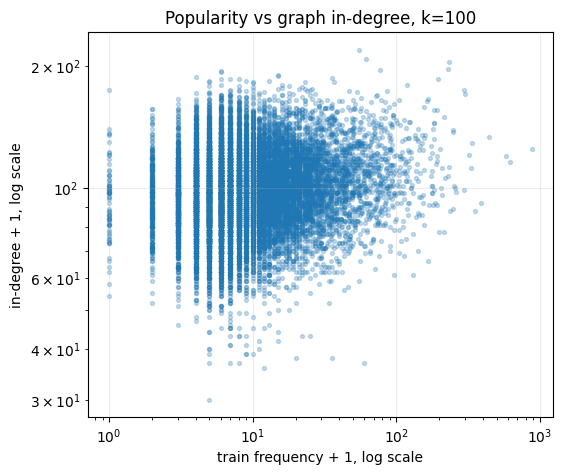

,k,bucket,bucket_min,bucket_max,n_items,train_frequency_mean,indegree_mean,indegree_median,indegree_p90,indegree_max
20,100,0-5,0,5.0,7210,3.784743,96.355340,94.0,123.0,194
21,100,6-10,6,10.0,5666,7.521179,98.522944,97.0,127.0,185
22,100,11-20,11,20.0,3140,14.486943,100.964650,99.0,129.0,189
23,100,21-50,21,50.0,1748,30.582952,104.134439,102.5,133.3,186
24,100,51+,51,NaN,593,94.924115,110.175379,108.0,142.8,219


In [8]:
k = int(summary['k'].max())
items = item_metrics[item_metrics['k'] == k].copy()

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(
    (items['train_frequency'] + 1),
    (items['indegree'] + 1),
    s=8,
    alpha=0.25,
)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('train frequency + 1, log scale')
ax.set_ylabel('in-degree + 1, log scale')
ax.set_title(f'Popularity vs graph in-degree, k={k}')
ax.grid(alpha=0.25)
plt.show()

popularity_buckets[popularity_buckets['k'] == k]

- `train_frequency`: how often an item appears in the training split.
- `in-degree`: how often the item is selected as a graph neighbor.
- A strong upward trend would mean popular items become graph hubs.
- The bucket table makes the same comparison after grouping items by popularity.
- Main takeaway: the relation is positive but weak, so popularity is probably not the main explanation for saturation.


## Dynamic B Analysis

These cells analyze actual graph decoding traces. They use the same graph-analysis session as the static section. If `dynamic/per_example.parquet` is not present yet, the cells print a short message and do nothing else.


In [9]:
dynamic_paths = {
    'per_example': DYNAMIC / 'per_example.parquet',
    'sample_traces': DYNAMIC / 'traces' / 'sample_traces.jsonl',
    'reachability': DYNAMIC / 'summaries' / 'dynamic_reachability_summary.csv',
    'redundancy': DYNAMIC / 'summaries' / 'dynamic_redundancy_summary.csv',
    'first_hit': DYNAMIC / 'summaries' / 'dynamic_first_hit_summary.csv',
    'saturation': DYNAMIC / 'summaries' / 'dynamic_saturation_summary.csv',
}

dynamic_available = dynamic_paths['per_example'].is_file()

if dynamic_available:
    dyn = pd.read_parquet(dynamic_paths['per_example'])
    reachability = pd.read_csv(dynamic_paths['reachability'])
    redundancy = pd.read_csv(dynamic_paths['redundancy'])
    first_hit = pd.read_csv(dynamic_paths['first_hit'])
    saturation = pd.read_csv(dynamic_paths['saturation'])
    print(f"Loaded dynamic outputs from {DYNAMIC}")
    display(saturation)
else:
    print(f"Dynamic outputs not found yet under {DYNAMIC}")
    print("Run/finish the dynamic Slurm job, then rerun this section.")


Loaded dynamic outputs from /gpfs/home6/scur1202/RPG/artifacts/rpg/graph_analysis/sports/20260615T153949Z_job23882755/dynamic


,n_edges,n_examples,reachable_rate,target_selected_rate,mean_visited_items,final_new_item_count_mean,final_prefix1_count_mean,final_prefix2_count_mean,final_prefix4_count_mean,ndcg@5,ndcg@10,recall@5,recall@10
0,10,106794,0.264865,0.038214,1700.089443,40.742757,232.787020,1392.932871,1584.513353,0.018156,0.022079,0.025938,0.038214
1,20,106794,0.403824,0.042662,3194.296047,35.389086,246.250819,2626.800157,3003.294932,0.020289,0.024701,0.028934,0.042662
2,30,106794,0.489850,0.043635,4573.137002,25.305083,250.221857,3747.693691,4318.368551,0.020573,0.025161,0.029402,0.043635
3,50,106794,0.608021,0.044085,6988.396867,12.107347,252.527782,5623.335084,6613.401755,0.020766,0.025401,0.029702,0.044085
4,100,106794,0.779791,0.044310,11223.992069,1.989110,254.111888,8643.234161,10602.731858,0.020842,0.025504,0.029833,0.044310


### B1. Target Reachability

This asks whether graph decoding ever visits the ground-truth item. Here `ground truth` means the actual held-out/test target item for the user, not the nearest item to the hidden state. The gap between `reachable_rate` and `target_selected_rate` separates graph access from final selection.


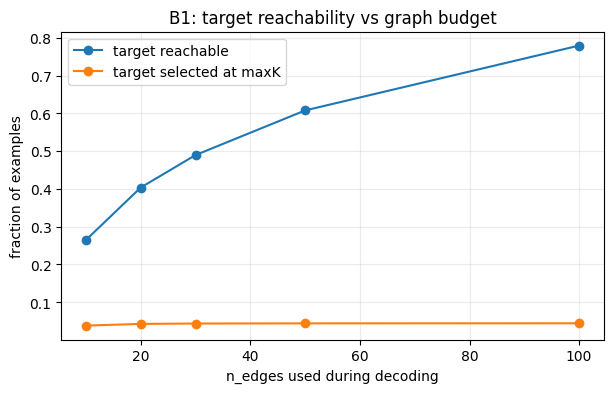

,n_edges,n_examples,reachable_rate,target_selected_rate,reachable_but_not_selected_rate,mean_visited_items
0,10,106794,0.264865,0.038214,0.226651,1700.089443
1,20,106794,0.403824,0.042662,0.361163,3194.296047
2,30,106794,0.489850,0.043635,0.446214,4573.137002
3,50,106794,0.608021,0.044085,0.563936,6988.396867
4,100,106794,0.779791,0.044310,0.735481,11223.992069


In [10]:
if dynamic_available:
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(reachability['n_edges'], reachability['reachable_rate'], marker='o', label='target reachable')
    ax.plot(reachability['n_edges'], reachability['target_selected_rate'], marker='o', label='target selected at maxK')
    ax.set_xlabel('n_edges used during decoding')
    ax.set_ylabel('fraction of examples')
    ax.set_title('B1: target reachability vs graph budget')
    ax.grid(alpha=0.25)
    ax.legend()
    plt.show()

    display(reachability)
else:
    print('B1 skipped: dynamic outputs not available yet.')


- `target reachable`: the held-out/test item appears somewhere in the cumulative visited set produced by graph decoding.
- `target selected at maxK`: the held-out/test item appears in the final generated list up to the evaluator maximum `topk`; for these plots this is equivalent to Recall@10.


What to check here:
- Does increasing graph budget make the held-out target much more reachable?
- Does final recommendation quality improve by the same amount, or does it saturate?
- If reachability grows but Recall/NDCG barely move, the likely bottleneck is ranking/scoring after access, not graph connectivity alone.


### B2. Redundancy of Visited Candidates

This checks whether extra propagation adds new areas or mostly repeats nearby/redundant candidates. Step `0` is the random initial beam set; later steps are graph expansions.


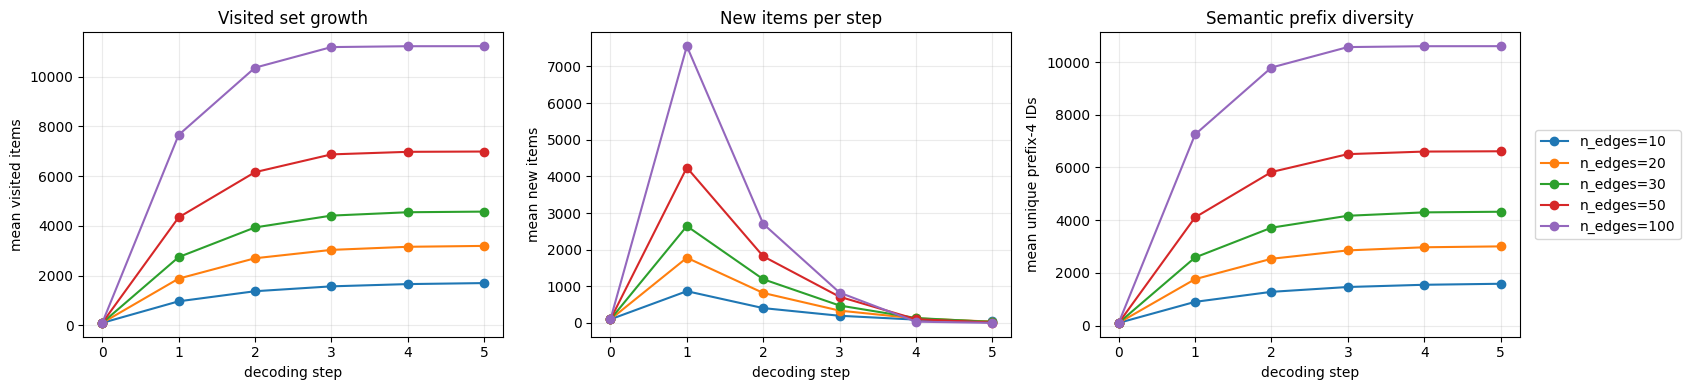

,n_edges,step,visited_count_mean,new_item_count_mean,unique_candidate_count_mean,duplicate_candidate_ratio_mean,novelty_ratio_mean,prefix1_count_mean,prefix2_count_mean,prefix4_count_mean
0,10,0,99.731970,99.731970,99.731970,0.002680,1.000000,80.926138,99.342707,99.648154
1,10,1,966.900294,867.168324,966.900294,0.033100,0.896844,216.153791,805.178203,897.979100
2,10,2,1372.355291,405.454997,623.464165,0.376536,0.649106,228.083937,1135.230828,1278.436017
3,10,3,1568.534375,196.179083,463.916522,0.536083,0.420155,231.118743,1289.604041,1461.597206
4,10,4,1659.346686,90.812312,389.292320,0.610708,0.230112,232.280081,1360.727251,1546.401549
5,10,5,1700.089443,40.742757,361.449950,0.638550,0.110005,232.787020,1392.932871,1584.513353
6,20,0,99.731970,99.731970,99.731970,0.002680,1.000000,80.926138,99.342707,99.648154
7,20,1,1879.150495,1779.418525,1879.150495,0.060425,0.946920,239.521556,1571.814091,1759.617198
8,20,2,2697.877708,818.727213,1132.756204,0.433622,0.720373,244.397906,2230.943330,2532.864393
9,20,3,3034.372380,336.494672,779.357838,0.610321,0.425693,245.653848,2497.866125,2851.287769


In [11]:
if dynamic_available:
    fig, axes = plt.subplots(1, 3, figsize=(17, 4))

    for n_edges, group in redundancy.groupby('n_edges'):
        axes[0].plot(group['step'], group['visited_count_mean'], marker='o', label=f'n_edges={n_edges}')
        axes[1].plot(group['step'], group['new_item_count_mean'], marker='o', label=f'n_edges={n_edges}')
        axes[2].plot(group['step'], group['prefix4_count_mean'], marker='o', label=f'n_edges={n_edges}')

    axes[0].set_title('Visited set growth')
    axes[0].set_ylabel('mean visited items')
    axes[1].set_title('New items per step')
    axes[1].set_ylabel('mean new items')
    axes[2].set_title('Semantic prefix diversity')
    axes[2].set_ylabel('mean unique prefix-4 IDs')

    for axis in axes:
        axis.set_xlabel('decoding step')
        axis.grid(alpha=0.25)
    axes[2].legend(loc='center left', bbox_to_anchor=(1.02, 0.5))
    plt.tight_layout()
    plt.show()

    display(redundancy.head(12))
else:
    print('B2 skipped: dynamic outputs not available yet.')


- `visited set growth`: total unique items visited so far.
- `new items per step`: marginal new items added at each step.
- `prefix-4 diversity`: how many distinct first-4-token semantic-ID prefixes appear in the visited set.



Read this as a redundancy check. If visited-set size grows while prefix diversity or target selection saturates, larger graph budgets are mostly adding nearby/repeated candidates rather than useful new ranking opportunities.


### B4. First-Hit / Path-Depth Analysis

This asks when the target is first reached during actual decoding. This is not a shortest-path computation: it includes RPG's real beam pruning.


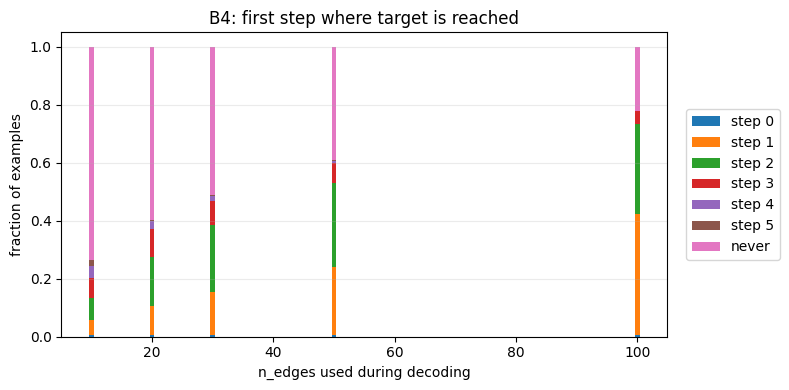

,n_edges,n_examples,first_reached_step_0_rate,first_reached_step_1_rate,first_reached_step_2_rate,first_reached_step_3_rate,first_reached_step_4_rate,first_reached_step_5_rate,never_reached_rate,mean_first_reached_step_reachable,median_first_reached_step_reachable
0,10,106794,0.00501,0.050518,0.076090,0.071558,0.041875,0.019814,0.735135,2.582231,3.0
1,20,106794,0.00501,0.101232,0.169785,0.093648,0.027717,0.006433,0.596176,2.141469,2.0
2,30,106794,0.00501,0.147930,0.233159,0.083329,0.017248,0.003174,0.510150,1.937530,2.0
3,50,106794,0.00501,0.234114,0.291861,0.066951,0.009008,0.001077,0.391979,1.743536,2.0
4,100,106794,0.00501,0.416540,0.310841,0.044937,0.002341,0.000122,0.220209,1.517082,1.0


In [12]:
if dynamic_available:
    step_cols = [col for col in first_hit.columns if col.startswith('first_reached_step_') and col.endswith('_rate')]
    plot_cols = step_cols + ['never_reached_rate']
    labels = [col.replace('first_reached_step_', 'step ').replace('_rate', '') for col in step_cols] + ['never']

    bottom = np.zeros(len(first_hit))
    fig, ax = plt.subplots(figsize=(8, 4))
    for col, label in zip(plot_cols, labels):
        values = first_hit[col].to_numpy()
        ax.bar(first_hit['n_edges'], values, bottom=bottom, label=label)
        bottom += values
    ax.set_xlabel('n_edges used during decoding')
    ax.set_ylabel('fraction of examples')
    ax.set_title('B4: first step where target is reached')
    ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5))
    ax.grid(axis='y', alpha=0.25)
    plt.tight_layout()
    plt.show()

    display(first_hit)
else:
    print('B4 skipped: dynamic outputs not available yet.')


- Early first-hit mass means targets that are reachable are usually found quickly.
- A large `never` segment means the graph search never reaches many targets under this budget.
- If deeper steps rarely add target hits, increasing propagation depth is unlikely to help much.


This plot tells us whether useful reachability happens early or whether deeper propagation is still adding target hits. If most reachable targets appear in the first few steps, extra depth is probably redundant. If later steps add many target hits, depth may still matter.


### B6. Saturation Curves

This puts recommendation quality and dynamic diagnostics on the same budget axis, but keeps reachability and ranking metrics on separate y-axes/subplots because they are different quantities. The point is to see whether performance saturates together with reachability/diversity.


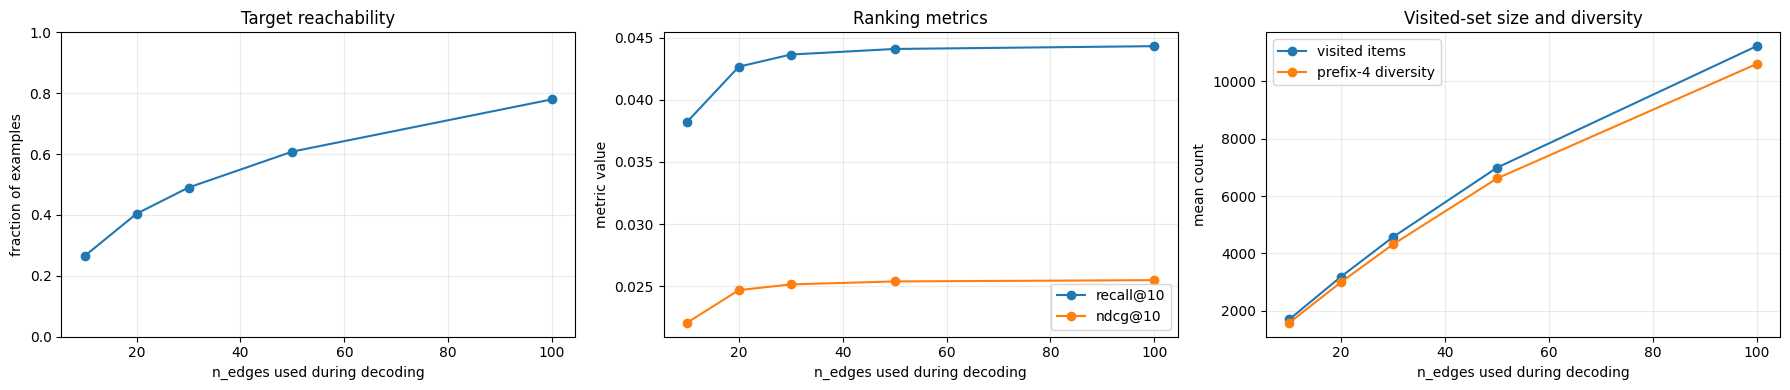

,n_edges,n_examples,reachable_rate,target_selected_rate,mean_visited_items,final_new_item_count_mean,final_prefix1_count_mean,final_prefix2_count_mean,final_prefix4_count_mean,ndcg@5,ndcg@10,recall@5,recall@10
0,10,106794,0.264865,0.038214,1700.089443,40.742757,232.787020,1392.932871,1584.513353,0.018156,0.022079,0.025938,0.038214
1,20,106794,0.403824,0.042662,3194.296047,35.389086,246.250819,2626.800157,3003.294932,0.020289,0.024701,0.028934,0.042662
2,30,106794,0.489850,0.043635,4573.137002,25.305083,250.221857,3747.693691,4318.368551,0.020573,0.025161,0.029402,0.043635
3,50,106794,0.608021,0.044085,6988.396867,12.107347,252.527782,5623.335084,6613.401755,0.020766,0.025401,0.029702,0.044085
4,100,106794,0.779791,0.044310,11223.992069,1.989110,254.111888,8643.234161,10602.731858,0.020842,0.025504,0.029833,0.044310


In [13]:
if dynamic_available:
    metric_candidates = [col for col in saturation.columns if col.startswith('recall@') or col.startswith('ndcg@')]
    preferred = [metric for metric in ['recall@10', 'ndcg@10'] if metric in metric_candidates]
    metrics_to_plot = preferred if preferred else metric_candidates[:2]

    fig, axes = plt.subplots(1, 3, figsize=(18, 4))

    axes[0].plot(saturation['n_edges'], saturation['reachable_rate'], marker='o', label='reachable_rate')
    axes[0].set_title('Target reachability')
    axes[0].set_xlabel('n_edges used during decoding')
    axes[0].set_ylabel('fraction of examples')
    axes[0].set_ylim(0, 1)
    axes[0].grid(alpha=0.25)

    for metric in metrics_to_plot:
        axes[1].plot(saturation['n_edges'], saturation[metric], marker='o', label=metric)
    axes[1].set_title('Ranking metrics')
    axes[1].set_xlabel('n_edges used during decoding')
    axes[1].set_ylabel('metric value')
    axes[1].legend()
    axes[1].grid(alpha=0.25)

    axes[2].plot(saturation['n_edges'], saturation['mean_visited_items'], marker='o', label='visited items')
    axes[2].plot(saturation['n_edges'], saturation['final_prefix4_count_mean'], marker='o', label='prefix-4 diversity')
    axes[2].set_title('Visited-set size and diversity')
    axes[2].set_xlabel('n_edges used during decoding')
    axes[2].set_ylabel('mean count')
    axes[2].legend()
    axes[2].grid(alpha=0.25)

    plt.tight_layout()
    plt.show()

    display(saturation)
else:
    print('B6 skipped: dynamic outputs not available yet.')


Use the run metadata above for the fixed `propagation_steps`, `num_beams`, and temperature. The budget axis here is `n_edges`, not the number of propagation steps.


Read this section as two separate questions: does graph decoding reach the true item, and does it put that item in the final top-k? If reachability rises much faster than Recall@10 / target-selected rate, then access is not the only bottleneck.


### B7. Beam-Budget Diagnostic

This checks whether increasing RPG's coupled beam/search budget makes reached targets more often selected. It is a lightweight follow-up: fixed `n_edges=100`, fixed depth, one seed, and a small user subset. Important caveat: `num_beams` changes the initial random pool, expanded frontier size, candidate count, and kept beam size together, so this is not an isolated pruning-only intervention.

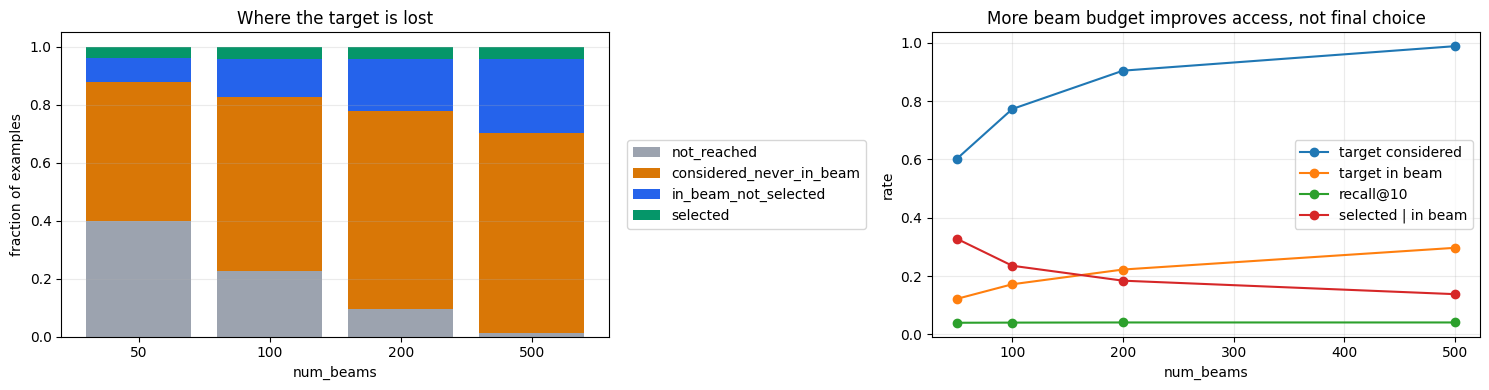

,num_beams,target_considered_rate,target_in_beam_rate,recall@10,selected_given_considered,selected_given_in_beam,not_reached_rate,considered_never_in_beam_rate,in_beam_not_selected_rate,selected_rate,mean_visited_items
0,50,0.6025,0.1220,0.0400,0.066390,0.327869,0.3975,0.4805,0.0820,0.0400,7586.6055
1,100,0.7730,0.1720,0.0405,0.052393,0.235465,0.2270,0.6010,0.1315,0.0405,11411.9235
2,200,0.9045,0.2225,0.0410,0.045329,0.184270,0.0955,0.6820,0.1815,0.0410,15227.3170
3,500,0.9885,0.2970,0.0410,0.041477,0.138047,0.0115,0.6915,0.2560,0.0410,17989.4230


In [14]:
pruning_paths = {
    'per_example': DYNAMIC / 'pruning' / 'per_example.parquet',
    'summary': DYNAMIC / 'pruning' / 'summaries' / 'pruning_summary.csv',
}
pruning_available = pruning_paths['per_example'].is_file() and pruning_paths['summary'].is_file()

if pruning_available:
    pruning = pd.read_parquet(pruning_paths['per_example'])
    pruning_summary = pd.read_csv(pruning_paths['summary'])

    # Extra conditional rates make the beam-budget-vs-ranking question clearer.
    conditional_rows = []
    for num_beams, group in pruning.groupby('num_beams', sort=True):
        considered = group['target_considered'].sum()
        in_beam = group['target_in_beam'].sum()
        selected = group['target_selected'].sum()
        conditional_rows.append({
            'num_beams': num_beams,
            'selected_given_considered': selected / considered if considered else np.nan,
            'selected_given_in_beam': selected / in_beam if in_beam else np.nan,
        })
    pruning_conditional = pd.DataFrame(conditional_rows)
    pruning_plot = pruning_summary.merge(pruning_conditional, on='num_beams', how='left')

    bucket_cols = [
        'not_reached_rate',
        'considered_never_in_beam_rate',
        'in_beam_not_selected_rate',
        'selected_rate',
    ]
    colors = ['#9ca3af', '#d97706', '#2563eb', '#059669']

    fig, axes = plt.subplots(1, 2, figsize=(15, 4))
    bottom = np.zeros(len(pruning_plot))
    x = np.arange(len(pruning_plot))
    for col, color in zip(bucket_cols, colors):
        axes[0].bar(x, pruning_plot[col], bottom=bottom, label=col.replace('_rate', ''), color=color)
        bottom += pruning_plot[col].to_numpy()
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(pruning_plot['num_beams'])
    axes[0].set_xlabel('num_beams')
    axes[0].set_ylabel('fraction of examples')
    axes[0].set_title('Where the target is lost')
    axes[0].legend(loc='center left', bbox_to_anchor=(1.02, 0.5))
    axes[0].grid(axis='y', alpha=0.25)

    axes[1].plot(pruning_plot['num_beams'], pruning_plot['target_considered_rate'], marker='o', label='target considered')
    axes[1].plot(pruning_plot['num_beams'], pruning_plot['target_in_beam_rate'], marker='o', label='target in beam')
    axes[1].plot(pruning_plot['num_beams'], pruning_plot['recall@10'], marker='o', label='recall@10')
    axes[1].plot(pruning_plot['num_beams'], pruning_plot['selected_given_in_beam'], marker='o', label='selected | in beam')
    axes[1].set_xlabel('num_beams')
    axes[1].set_ylabel('rate')
    axes[1].set_title('More beam budget improves access, not final choice')
    axes[1].legend()
    axes[1].grid(alpha=0.25)

    plt.tight_layout()
    plt.show()

    display(pruning_plot[[
        'num_beams',
        'target_considered_rate',
        'target_in_beam_rate',
        'recall@10',
        'selected_given_considered',
        'selected_given_in_beam',
        'not_reached_rate',
        'considered_never_in_beam_rate',
        'in_beam_not_selected_rate',
        'selected_rate',
        'mean_visited_items',
    ]])
else:
    print('B7 skipped: beam-budget outputs not available yet.')

- `target considered`: the target appeared in the candidate set at some step.
- `target in beam`: the target survived scoring into a beam at least once in that run.
- `selected | in beam`: among cases where the target entered the beam, how often it ended in final top-10.
- Main takeaway so far: larger `num_beams` makes the target much easier to consider and more likely to enter the beam, but Recall@10 barely changes. Since `num_beams` is a coupled search-budget knob, this does not causally isolate pruning; it says that simply spending more RPG beam/search budget is not enough.

### B8. Novelty-Aware Traversal

This is a lightweight intervention diagnostic, not a full benchmark. It uses one seed (`2024`), the first `5000` Sports test users, `num_beams=100`, `propagation_steps=5`, and only `n_edges=[30, 100]`.

The original RPG traversal can repeatedly select already-seen nodes into the next frontier. The `visited_masked` variant prefers unvisited candidates when choosing the next frontier, while keeping the same graph and scoring rule.

The question is: does forcing more exploration improve recommendation quality, or does it only increase reachability?

,mode,n_edges,users,reachable_%,recall@10_%,ndcg@10_x100,mean_visited_items
0,original,30,5000,46.74,3.92,2.35,4580.0
1,original,100,5000,77.12,3.94,2.36,11241.0
2,visited_masked,30,5000,62.00,0.54,0.29,6649.0
3,visited_masked,100,5000,93.18,0.20,0.12,15298.0


,mode,n_edges,new_items_at_final_step,frontier_seen_before_%
5,original,30,27.4,99.40
11,original,100,2.2,99.99
17,visited_masked,30,1032.4,0.00
23,visited_masked,100,1324.9,0.00


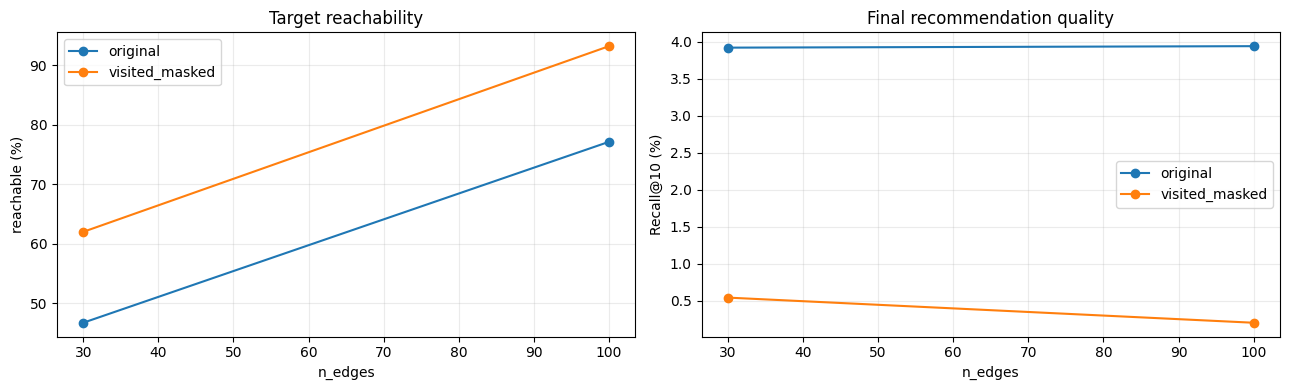

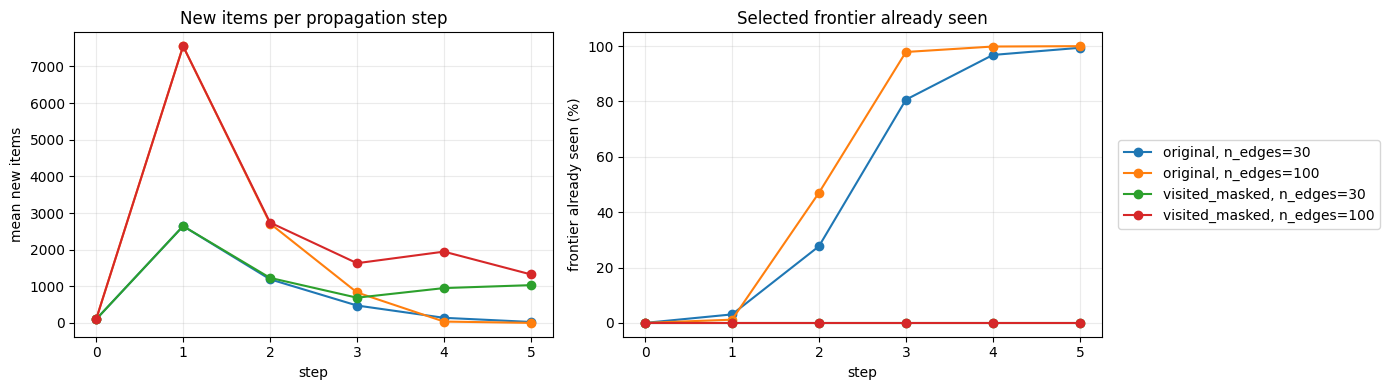

In [15]:
novelty_paths = {
    'per_example': DYNAMIC / 'novelty' / 'per_example.parquet',
    'summary': DYNAMIC / 'novelty' / 'summaries' / 'novelty_summary.csv',
    'redundancy': DYNAMIC / 'novelty' / 'summaries' / 'novelty_redundancy_summary.csv',
}
novelty_available = all(path.is_file() for path in novelty_paths.values())

if novelty_available:
    novelty = pd.read_parquet(novelty_paths['per_example'])
    novelty_summary = pd.read_csv(novelty_paths['summary'])
    novelty_redundancy = pd.read_csv(novelty_paths['redundancy'])

    summary_table = (
        novelty_summary[[
            'mode',
            'n_edges',
            'n_examples',
            'reachable_rate',
            'recall@10',
            'ndcg@10',
            'mean_visited_items',
        ]]
        .assign(
            reachable_pct=lambda d: 100 * d['reachable_rate'],
            recall10_pct=lambda d: 100 * d['recall@10'],
            ndcg10_pct=lambda d: 100 * d['ndcg@10'],
        )[[
            'mode',
            'n_edges',
            'n_examples',
            'reachable_pct',
            'recall10_pct',
            'ndcg10_pct',
            'mean_visited_items',
        ]]
        .rename(columns={
            'mode': 'mode',
            'n_edges': 'n_edges',
            'n_examples': 'users',
            'reachable_pct': 'reachable_%',
            'recall10_pct': 'recall@10_%',
            'ndcg10_pct': 'ndcg@10_x100',
            'mean_visited_items': 'mean_visited_items',
        })
        .round({
            'reachable_%': 2,
            'recall@10_%': 2,
            'ndcg@10_x100': 2,
            'mean_visited_items': 0,
        })
    )
    display(summary_table)

    final_step_table = (
        novelty_redundancy[novelty_redundancy['step'] == novelty_redundancy['step'].max()][[
            'mode',
            'n_edges',
            'new_item_count_mean',
            'frontier_seen_before_ratio_mean',
        ]]
        .assign(frontier_seen_before_pct=lambda d: 100 * d['frontier_seen_before_ratio_mean'])
        .drop(columns=['frontier_seen_before_ratio_mean'])
        .rename(columns={
            'new_item_count_mean': 'new_items_at_final_step',
            'frontier_seen_before_pct': 'frontier_seen_before_%',
        })
        .round({
            'new_items_at_final_step': 1,
            'frontier_seen_before_%': 2,
        })
    )
    display(final_step_table)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    for mode, group in novelty_summary.groupby('mode'):
        group = group.sort_values('n_edges')
        axes[0].plot(group['n_edges'], 100 * group['reachable_rate'], marker='o', label=mode)
        axes[1].plot(group['n_edges'], 100 * group['recall@10'], marker='o', label=mode)

    axes[0].set_title('Target reachability')
    axes[0].set_xlabel('n_edges')
    axes[0].set_ylabel('reachable (%)')
    axes[0].grid(alpha=0.25)
    axes[0].legend()

    axes[1].set_title('Final recommendation quality')
    axes[1].set_xlabel('n_edges')
    axes[1].set_ylabel('Recall@10 (%)')
    axes[1].grid(alpha=0.25)
    axes[1].legend()
    plt.tight_layout()
    plt.show()

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    for (mode, n_edges), group in novelty_redundancy.groupby(['mode', 'n_edges']):
        group = group.sort_values('step')
        label = f'{mode}, n_edges={n_edges}'
        axes[0].plot(group['step'], group['new_item_count_mean'], marker='o', label=label)
        axes[1].plot(group['step'], 100 * group['frontier_seen_before_ratio_mean'], marker='o', label=label)

    axes[0].set_title('New items per propagation step')
    axes[0].set_xlabel('step')
    axes[0].set_ylabel('mean new items')
    axes[0].grid(alpha=0.25)

    axes[1].set_title('Selected frontier already seen')
    axes[1].set_xlabel('step')
    axes[1].set_ylabel('frontier already seen (%)')
    axes[1].grid(alpha=0.25)
    axes[1].legend(loc='center left', bbox_to_anchor=(1.02, 0.5))
    plt.tight_layout()
    plt.show()
else:
    print('B8 skipped: novelty outputs not available yet.')

- `original`: standard RPG traversal, where already-seen nodes can re-enter the frontier.
- `visited_masked`: prefers unvisited candidates for the next frontier, backfilling only if too few fresh candidates exist.
- This diagnostic is intentionally small: one seed, 5000 users, and two graph widths. Treat it as directional evidence, not a final full benchmark.
- The intervention works mechanically: it keeps discovering many more new nodes and increases target reachability.
- It hurts final recommendation quality badly: for `n_edges=100`, Recall@10 drops from about `3.94%` to about `0.20%`.
- Interpretation: repeated revisiting is not just wasted traversal. In RPG it acts like exploitation/stabilization of high-scoring local regions. Forcing novelty improves exploration but moves the final frontier away from the candidates the model scores best.

### B9. Visited-Pool Reranking

This checks whether the final beam itself is losing useful candidates. Standard RPG traversal is unchanged. After traversal, the diagnostic scores every visited item with RPG's own semantic-token score and returns top-10 from the full visited pool.

This is still a lightweight diagnostic: one seed (`2024`), first `5000` Sports test users, `num_beams=100`, `propagation_steps=5`, and `n_edges=[30, 100]`.

The question is: if the target was reached somewhere in the traversal, would a global top-10 over all visited nodes recover it?


,n_edges,users,reachable_%,original_recall@10_%,visited_pool_recall@10_%,hit_gain_cases,prediction_changed_%,median_target_rank_in_pool
0,30,5000,46.74,3.92,3.92,0,17.92,416.0
1,100,5000,77.12,3.94,3.94,0,19.60,1319.5


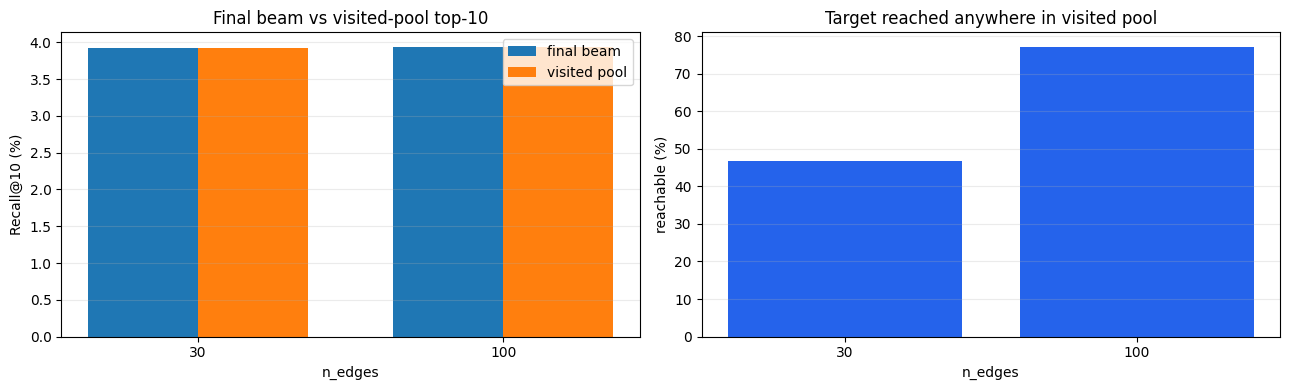

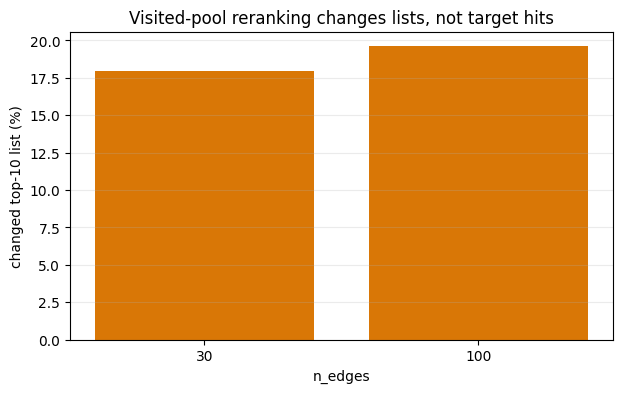

In [16]:
pool_paths = {
    'per_example': SESSION / 'rerank' / 'visited_pool' / 'rpg_graph_analysis_sports_pool_rerank' / 'per_example.parquet',
    'summary': SESSION / 'rerank' / 'visited_pool' / 'rpg_graph_analysis_sports_pool_rerank' / 'summaries' / 'visited_pool_summary.csv',
}
pool_available = all(path.is_file() for path in pool_paths.values())

if pool_available:
    pool = pd.read_parquet(pool_paths['per_example'])
    pool_summary = pd.read_csv(pool_paths['summary'])

    prediction_change = (
        pool.assign(prediction_changed=pool['original_predictions_json'] != pool['pool_predictions_json'])
        .groupby('n_edges', as_index=False)
        .agg(prediction_changed_rate=('prediction_changed', 'mean'))
    )
    pool_plot = pool_summary.merge(prediction_change, on='n_edges', how='left').sort_values('n_edges')

    pool_table = (
        pool_plot.assign(
            reachable_pct=lambda d: 100 * d['reachable_rate'],
            original_recall10_pct=lambda d: 100 * d['original_recall@10'],
            pool_recall10_pct=lambda d: 100 * d['pool_recall@10'],
            prediction_changed_pct=lambda d: 100 * d['prediction_changed_rate'],
            target_hit_gain_cases=lambda d: (d['pool_gain_rate'] * d['n_examples']).round().astype(int),
        )[[
            'n_edges',
            'n_examples',
            'reachable_pct',
            'original_recall10_pct',
            'pool_recall10_pct',
            'target_hit_gain_cases',
            'prediction_changed_pct',
            'median_target_rank_in_visited_pool',
        ]]
        .rename(columns={
            'n_examples': 'users',
            'reachable_pct': 'reachable_%',
            'original_recall10_pct': 'original_recall@10_%',
            'pool_recall10_pct': 'visited_pool_recall@10_%',
            'target_hit_gain_cases': 'hit_gain_cases',
            'prediction_changed_pct': 'prediction_changed_%',
            'median_target_rank_in_visited_pool': 'median_target_rank_in_pool',
        })
        .round({
            'reachable_%': 2,
            'original_recall@10_%': 2,
            'visited_pool_recall@10_%': 2,
            'prediction_changed_%': 2,
            'median_target_rank_in_pool': 1,
        })
    )
    display(pool_table)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    x = np.arange(len(pool_plot))
    width = 0.36

    axes[0].bar(x - width / 2, 100 * pool_plot['original_recall@10'], width, label='final beam')
    axes[0].bar(x + width / 2, 100 * pool_plot['pool_recall@10'], width, label='visited pool')
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(pool_plot['n_edges'])
    axes[0].set_xlabel('n_edges')
    axes[0].set_ylabel('Recall@10 (%)')
    axes[0].set_title('Final beam vs visited-pool top-10')
    axes[0].legend()
    axes[0].grid(axis='y', alpha=0.25)

    axes[1].bar(x, 100 * pool_plot['reachable_rate'], color='#2563eb')
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(pool_plot['n_edges'])
    axes[1].set_xlabel('n_edges')
    axes[1].set_ylabel('reachable (%)')
    axes[1].set_title('Target reached anywhere in visited pool')
    axes[1].grid(axis='y', alpha=0.25)

    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.bar(pool_plot['n_edges'].astype(str), 100 * pool_plot['prediction_changed_rate'], color='#d97706')
    ax.set_xlabel('n_edges')
    ax.set_ylabel('changed top-10 list (%)')
    ax.set_title('Visited-pool reranking changes lists, not target hits')
    ax.grid(axis='y', alpha=0.25)
    plt.show()
else:
    print('B9 skipped: visited-pool reranking outputs are not available yet.')


- `final beam`: current RPG output after the last propagation step.
- `visited pool`: top-10 over every item visited during standard traversal, scored with the same RPG semantic-token score.
- This is not a new learned reranker. It only asks whether the final beam loses items that RPG already visited and already scores well.
- Result: Recall@10 is unchanged for both graph widths, and there are zero target-hit gains/losses.
- The top-10 list changes for some users, but not in a way that recovers the ground-truth item.
- Interpretation: the missed reachable targets are usually not high-ranked under RPG's own score. The bottleneck is therefore not just "final beam vs all visited nodes"; it is more likely the scoring/ranking signal itself.


### B10. Frontier Memory Diagnostic

This diagnostic tests whether repeated frontier re-entry is just wasted compute or whether it is acting like implicit candidate memory. The setup is Sports, full test set, three eval seeds, `n_edges=100`, `num_beams=100`, `propagation_steps=5`, and `memory_size=100`.

- `original`: standard RPG graph decoding.
- `prefer_unvisited`: pushes the frontier toward fresh nodes, with fallback if too few fresh nodes exist.
- `prefer_unvisited_memory`: uses the same prefer-unvisited traversal, but chooses final top-10 from the best RPG-scored visited candidates.


In [3]:
frontier_full = SESSION / 'dynamic' / 'frontier_memory' / 'rpg_graph_analysis_sports_frontier_memory_full' / 'summaries' / 'frontier_memory_summary.csv'
if frontier_full.is_file():
    fm = pd.read_csv(frontier_full)
    fm_display = fm.assign(
        reachable_pct=100 * fm['reachable_rate'],
        recall10_pct=100 * fm['recall@10'],
        ndcg10_pct=100 * fm['ndcg@10'],
    )[[
        'variant', 'n_examples', 'reachable_pct', 'recall10_pct', 'ndcg10_pct',
        'mean_visited_items', 'mean_frontier_duplicate_selection_rate',
        'mean_graph_seconds_per_user', 'mean_memory_seconds_per_user',
    ]]
    display(
        fm_display.rename(columns={
            'reachable_pct': 'Reachable (%)',
            'recall10_pct': 'Recall@10 (%)',
            'ndcg10_pct': 'NDCG@10 (%)',
            'mean_visited_items': 'Mean visited items',
            'mean_frontier_duplicate_selection_rate': 'Frontier duplicate rate',
            'mean_graph_seconds_per_user': 'Graph sec/user',
            'mean_memory_seconds_per_user': 'Memory sec/user',
        }).style.format({
            'Reachable (%)': '{:.2f}',
            'Recall@10 (%)': '{:.3f}',
            'NDCG@10 (%)': '{:.3f}',
            'Mean visited items': '{:,.0f}',
            'Frontier duplicate rate': '{:.3f}',
            'Graph sec/user': '{:.4f}',
            'Memory sec/user': '{:.4f}',
        })
    )
else:
    print(f'Missing frontier-memory full summary: {frontier_full}')


,variant,n_examples,Reachable (%),Recall@10 (%),NDCG@10 (%),Mean visited items,Frontier duplicate rate,Graph sec/user,Memory sec/user
0,original,106794,77.98,4.431,2.550,"11,224",0.578,0.0127,0.0000
1,prefer_unvisited,106794,93.10,0.161,0.086,"15,276",0.000,0.0210,0.0000
2,prefer_unvisited_memory,106794,93.10,4.433,2.543,"15,276",0.000,0.0210,0.0030


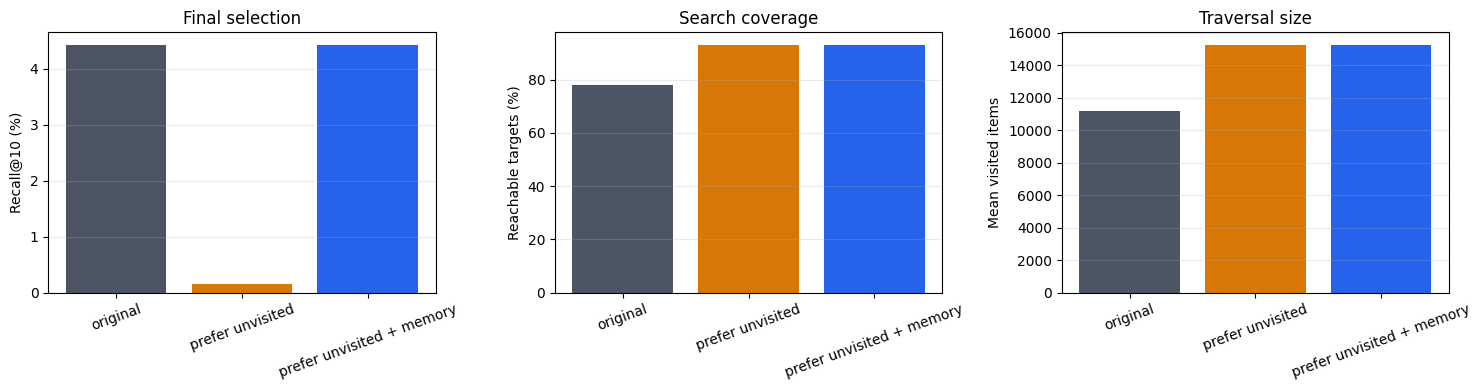

In [4]:
if frontier_full.is_file():
    plot_df = fm.copy()
    labels = {
        'original': 'original',
        'prefer_unvisited': 'prefer unvisited',
        'prefer_unvisited_memory': 'prefer unvisited + memory',
    }
    plot_df['label'] = plot_df['variant'].map(labels)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    axes[0].bar(plot_df['label'], 100 * plot_df['recall@10'], color=['#4b5563', '#d97706', '#2563eb'])
    axes[0].set_title('Final selection')
    axes[0].set_ylabel('Recall@10 (%)')
    axes[0].tick_params(axis='x', rotation=20)

    axes[1].bar(plot_df['label'], 100 * plot_df['reachable_rate'], color=['#4b5563', '#d97706', '#2563eb'])
    axes[1].set_title('Search coverage')
    axes[1].set_ylabel('Reachable targets (%)')
    axes[1].tick_params(axis='x', rotation=20)

    axes[2].bar(plot_df['label'], plot_df['mean_visited_items'], color=['#4b5563', '#d97706', '#2563eb'])
    axes[2].set_title('Traversal size')
    axes[2].set_ylabel('Mean visited items')
    axes[2].tick_params(axis='x', rotation=20)

    for ax in axes:
        ax.grid(axis='y', alpha=0.25)
    plt.tight_layout()
    plt.show()


The useful result is not that this is a better decoder. It is not faster and it does not improve Recall. The useful result is interpretive: forcing exploration makes the target reachable much more often but destroys final Recall; adding explicit candidate memory recovers the original Recall. This supports the idea that repeated re-entry in RPG is acting as implicit candidate memory or stabilization, not just redundant graph work.


### Sample Trace Inspection

This is for qualitative debugging only. It loads a small deterministic sample of full traces if the dynamic job wrote them.


In [17]:
if dynamic_available and dynamic_paths['sample_traces'].is_file():
    with dynamic_paths['sample_traces'].open() as handle:
        sample_traces = [json.loads(line) for line in handle]
    print(f'Loaded {len(sample_traces)} sampled traces')
    if sample_traces:
        trace = sample_traces[0]
        print({
            'user_index': trace['user_index'],
            'eval_seed': trace['eval_seed'],
            'n_edges': trace['n_edges'],
            'target_item_id': trace['target_item_id'],
            'prediction_head': trace['predictions'][:10],
            'n_initial_items': len(trace['initial_items']),
            'n_final_visited_items': len(trace['final_visited_items']),
        })
else:
    print('Sample traces not available yet.')


Loaded 1920 sampled traces
{'user_index': 164, 'eval_seed': 2024, 'n_edges': 10, 'target_item_id': 1282, 'prediction_head': [1545, 1220, 5778, 1359, 1253, 1296, 1279, 7380, 1467, 1420], 'n_initial_items': 100, 'n_final_visited_items': 1905}


## Final Takeaways

Fill this section after running the cells for this dataset. Keep the interpretation separated by block:

### A. Static Graph Structure

- Is the graph semantically meaningful compared with random pairs?
- Is the weak largest component already close to 1.0?
- Is the directed strong component also large, or does direction still constrain traversal?
- How clustered/redundant are neighborhoods?
- Does hubness correlate strongly with training popularity?

### B. Dynamic Decoding

- Does larger `n_edges` mainly improve reachability, ranking metrics, or both?
- Are targets reached early or only after deeper propagation?
- Does visited-set growth become redundant at larger graph budgets?
- If beam-budget diagnostics exist, interpret them as coupled search-budget effects, not isolated pruning effects.

### C. Scoring vs Graph Decoding

- Compare graph decoding against exhaustive RPG scoring over all items.
- If graph Recall@10 is close to brute-force RPG Recall@10, graph traversal is not the main bottleneck.
- If there is a large gap, graph search/candidate access is still losing useful items.


## Experiment C: Scoring vs Graph Decoding

This is the cleanest bottleneck check.

Question 1: if RPG scores **all items** with its own token scorer, how often is the true item in the top-10?

Question 2: if the true item is already in that brute-force RPG top-10, does graph decoding recover it?

So the interpretation is simple: if brute-force RPG is low, the scoring/model is the bottleneck. If brute-force RPG is high but graph decoding is low, graph search is the bottleneck.


In [18]:
SCORING = SESSION / 'scoring'
PERF = SESSION / 'perf_inference'

scoring_paths = {
    'bruteforce': SCORING / 'bruteforce_per_user.parquet',
    'graph': SCORING / 'graph_per_example.parquet',
    'bf_summary': SCORING / 'summaries' / 'bruteforce_summary.csv',
    'graph_summary': SCORING / 'summaries' / 'graph_overlap_summary.csv',
}
perf_paths = {
    'summary': PERF / 'perf_summary.csv',
    'raw': PERF / 'perf_raw.csv',
}

scoring_available = all(path.is_file() for path in scoring_paths.values())
perf_available = all(path.is_file() for path in perf_paths.values())
print(f'Experiment C available: {scoring_available}')
print(f'Inference perf available: {perf_available}')

if not scoring_available:
    missing = [name for name, path in scoring_paths.items() if not path.is_file()]
    print('Missing scoring files:', missing)
else:
    bf_users = pd.read_parquet(scoring_paths['bruteforce'])
    c_graph = pd.read_parquet(scoring_paths['graph'])
    bf_summary = pd.read_csv(scoring_paths['bf_summary'])
    c_summary = pd.read_csv(scoring_paths['graph_summary'])

    c_mean = c_summary[c_summary['aggregate'] == 'mean_across_seeds'].sort_values('n_edges').copy()

    # Compact one-line baseline: this is the upper bound for RPG's current scorer.
    c0_scoring_baseline = pd.DataFrame([{
        'users': int(bf_summary['n_examples'].iloc[0]),
        'BF RPG Recall@10 (%)': 100 * float(bf_summary['bf_recall@10'].iloc[0]),
        'BF RPG NDCG@10 (%)': 100 * float(bf_summary['bf_ndcg@10'].iloc[0]),
        'median true-item rank': float(bf_summary['bf_target_rank_median'].iloc[0]),
        'p90 true-item rank': float(bf_summary['bf_target_rank_p90'].iloc[0]),
    }]).round(3)

    # Main result table: all rate columns are percentages.
    grouped = c_graph.groupby('n_edges')
    c1_quality = pd.DataFrame({
        'n_edges': c_mean['n_edges'].astype(int),
        'Graph Recall@10 (%)': 100 * c_mean['graph_recall@10'],
        'BF RPG Recall@10 (%)': 100 * c_mean['bf_recall@10'],
        'Graph loss vs BF (pp)': 100 * (c_mean['bf_recall@10'] - c_mean['graph_recall@10']),
        'BF-top10 target missed by graph (%)': 100 * c_mean['target_bf_top10_graph_missed_rate'],
        'Recover target if BF top10 (%)': 100 * grouped.apply(
            lambda x: x.loc[x['target_in_bf_top10'], 'target_in_graph_top10'].mean(),
            include_groups=False,
        ).to_numpy(),
    }).round(3)

    # Search coverage table: all rate columns are percentages except visited items.
    c2_search_coverage = pd.DataFrame({
        'n_edges': c_mean['n_edges'].astype(int),
        'Target reachable (%)': 100 * c_mean['target_reachable_rate'],
        'Visit BF top-1 (%)': 100 * c_mean['visited_bf_top1_rate'],
        'Visit any BF top-10 (%)': 100 * c_mean['visited_any_bf_top10_rate'],
        'BF top-10 overlap (%)': 100 * c_mean['graph_top10_overlap_bf_top10_frac_mean'],
        'Mean visited items': c_mean['mean_visited_items'],
    }).round(3)

    if perf_available:
        perf_summary = pd.read_csv(perf_paths['summary'])
        perf_raw = pd.read_csv(perf_paths['raw'])
        brute_ms = float(
            perf_summary.loc[
                perf_summary['method'] == 'bruteforce_all_items',
                'ms_per_user_median',
            ].iloc[0]
        )
        c3_runtime_comparison = pd.DataFrame({
            'method': perf_summary['method'].replace({
                'bruteforce_all_items': 'brute-force RPG scoring',
                'graph_generate': 'upstream graph generate',
            }),
            'n_edges': perf_summary['n_edges'].apply(
                lambda value: 'all items' if pd.isna(value) else int(value)
            ),
            'repeats': perf_summary['repeats'].astype(int),
            'total seconds (median)': perf_summary['total_seconds_median'],
            'ms/user (median)': perf_summary['ms_per_user_median'],
            'users/s (median)': perf_summary['users_per_second_median'],
            'baseline alloc (GB)': perf_summary['baseline_cuda_allocated_gb_median'],
            'baseline reserved (GB)': perf_summary['baseline_cuda_reserved_gb_median'],
            'peak alloc (GB)': perf_summary['peak_cuda_allocated_gb_median'],
            'peak reserved (GB)': perf_summary['peak_cuda_reserved_gb_median'],
            'runtime alloc delta (GB)': perf_summary['peak_cuda_runtime_delta_allocated_gb_median'],
            'runtime reserved delta (GB)': perf_summary['peak_cuda_runtime_delta_reserved_gb_median'],
            'Recall@10 (%)': 100 * perf_summary['recall@10_median'],
            'NDCG@10 (%)': 100 * perf_summary['ndcg@10_median'],
        })
        c3_runtime_comparison['slowdown vs brute force'] = (
            perf_summary['ms_per_user_median'] / brute_ms
        )
        c3_runtime_comparison = c3_runtime_comparison.round(3)
    else:
        c3_runtime_comparison = pd.DataFrame()
        perf_raw = pd.DataFrame()

    display(c0_scoring_baseline)


Experiment C available: True
Inference perf available: True


,users,BF RPG Recall@10 (%),BF RPG NDCG@10 (%),median true-item rank,p90 true-item rank
0,35598,4.433,2.551,2123.0,12502.6


How to read the next tables:

- `BF RPG` means exhaustive scoring over all items with RPG's own token scorer. This is not a new model; it is the upper bound for the current RPG scorer.
- `Graph Recall@10` is normal graph decoding.
- `Graph loss vs BF` is the gap we would blame on graph search. Smaller is better.
- `Recover target if BF top10` asks: when RPG scoring already puts the true item in top-10, does graph decoding recover it?
- `Target reachable` is different: the true item appeared somewhere in the visited set, not necessarily in the final top-10.

Runtime table:

- This uses the separate no-trace `perf_inference` benchmark.
- Brute force is vectorized all-item RPG scoring over all real items in this dataset.
- Graph uses upstream `model.generate()` with the graph-analysis hparams and no trace bookkeeping.
- Timing uses warmup and repeated passes; the table reports medians.
- Memory columns are in GiB. `alloc` is live tensor memory tracked by PyTorch; `reserved` is memory held by the CUDA caching allocator.
- `baseline` is measured after method-specific persistent structures are loaded, before the timed pass.
- `peak` is the maximum during the timed pass.
- `runtime delta` is `peak - baseline`, matching the runtime-memory idea used in the repo performance profiling.


Write the dataset-specific conclusion here after reading Experiment C and `perf_inference`. The key comparison is whether graph decoding approaches the brute-force RPG scoring upper bound. If it does, the remaining error is mostly scoring/model quality; if it does not, graph traversal is still losing good RPG-scored candidates.
